<a href="https://colab.research.google.com/github/Nicopiwi/neuromatch_perceptual_estimation/blob/main/learning_priors.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Study Laquitaine & Gardner motion direction prior learning

author: steeve.laquitaine@epfl.ch

Inpired from [Laquitaine & Gardner, Neuron, 2017](https://www.cell.com/neuron/fulltext/S0896-6273(17)31134-0?_returnURL=https%3A%2F%2Flinkinghub.elsevier.com%2Fretrieve%2Fpii%2FS0896627317311340%3Fshowall%3Dtrue)

Purpose: show how subjects could compute a state prediction error signal and use it to learn the motion directions generative process. We chose a Gaussian generative process for simplicity. Circular distributions like Von Mises distributions are more appropriate for a circular space.






In [41]:
# @title Dependencies
import pandas as pd
from matplotlib import pyplot as plt
from matplotlib import rcParams
import numpy as np
import os
import numpy as np
from scipy.stats import norm, uniform
import copy
import random

In [30]:
# @title Figure settings
rcParams['figure.figsize'] = [20, 4]
rcParams['font.size'] = 11
rcParams['axes.spines.top'] = False
rcParams['axes.spines.right'] = False
rcParams['figure.autolayout'] = True

In [31]:
# @title Utils
def build_generative_model(std, mean):
    """create hidden generative process for motion direction
    the experimental Gaussian prior
    """
    # set direction state space
    x = np.arange(1, 360, 1)

    # calculate probability distribution
    pdf = norm.pdf(x, loc=mean, scale=std)
    pdf /= sum(pdf)
    return pdf

def generate_directions(mean, std, n_trials, seed):
    return np.round(norm.rvs(loc=mean, scale=std, size=n_trials, random_state=seed))


def learn_generative_process(motion_directions, learning_rate, x, n_trials):
    """learn the generative process
    """
    # set subject initial belief state
    initial_prior = uniform.pdf(x, loc=x[0], scale=x[-1])
    initial_prior /= sum(initial_prior)
    prior = copy(initial_prior)
    observed = np.zeros((len(x)))
    prediction_errors = []
    priors = []

    for old_trial in range(0, n_trials):

        # locate the observed state component
        state_loc = np.where(x == int(motion_directions[old_trial]))[0][0]

        # compute its state prediction error
        state_pred_error = learning_rate * (1 - prior[state_loc])

        # use the prediction error to update the state belief
        prior[state_loc] = prior[state_loc] + state_pred_error
        prior /= sum(prior)

        # tape
        prediction_errors.append(state_pred_error)
        priors.append(copy(prior))
    return priors

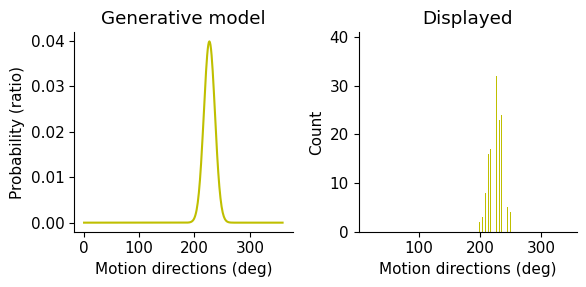

In [32]:
# @title Create first generative process (10 deg prior)
# set generative model parameters
MEAN = 227
STD = 10
N_TRIALS = 800
SEED = 0

# build generative model
x = np.arange(1, 360, 1)
pdf = build_generative_model(STD, MEAN)

# generate directions
directions_prior01 = generate_directions(mean=MEAN, std=STD, n_trials=N_TRIALS, seed=SEED)

# plot the generative process
fig, (ax1,ax2) = plt.subplots(1,2, figsize=(6,3));
ax1.plot(x, pdf, color=[0.75, 0.75, 0]);
ax1.set_title("Generative model");
ax1.set_ylabel("Probability (ratio)");
ax1.set_xlabel("Motion directions (deg)");

# plot generated motion direction distribution
ax2.hist(directions_prior01, color=[0.75, 0.75, 0], bins=180);
ax2.set_title("Displayed");
ax2.set_xlim([x[0], x[-1]]);
ax2.set_ylabel("Count");
ax2.set_xlabel("Motion directions (deg)");

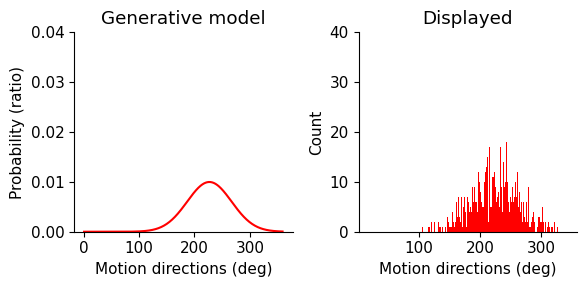

In [33]:
# @title Create second generative process (40 deg prior)
# set generative model parameters
MEAN = 227
STD = 40
N_TRIALS = 800
SEED = 0

# build generative model
x = np.arange(1, 360, 1)
pdf = build_generative_model(STD, MEAN)

# generate directions
directions_prior02 = generate_directions(mean=MEAN, std=STD, n_trials=N_TRIALS, seed=SEED)

# plot the generative process
fig, (ax1,ax2) = plt.subplots(1,2, figsize=(6,3));
ax1.plot(x, pdf, color=[1, 0, 0]);
ax1.set_ylim([0, 0.04]);
ax1.set_title("Generative model");
ax1.set_ylabel("Probability (ratio)");
ax1.set_xlabel("Motion directions (deg)");

# plot generated motion direction distribution
ax2.hist(directions_prior02, color=[1, 0, 0], bins=180);
ax2.set_ylim([0, 40]);
ax2.set_title("Displayed");
ax2.set_xlim([x[0], x[-1]]);
ax2.set_ylabel("Count");
ax2.set_xlabel("Motion directions (deg)");

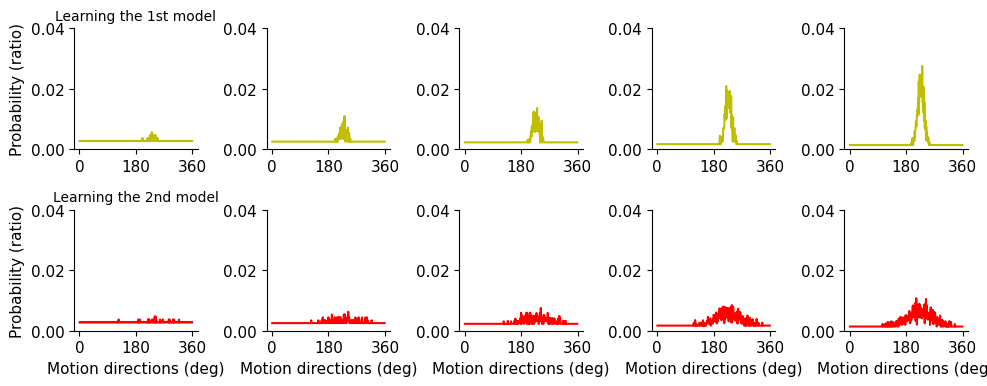

In [37]:
# @title Prior learning with a state prediction error (SPE)

# create initial prior
initial_prior = uniform.pdf(x, loc=x[0], scale=x[-1])
initial_prior /= sum(initial_prior)

# learn model 1
priors01 = learn_generative_process(directions_prior01, learning_rate=0.001, x=x, n_trials=800)

# learn model 2
priors02 = learn_generative_process(directions_prior02, learning_rate=0.001, x=x, n_trials=800)

# figure
steps = [20, 100, 200, 500, 700]
fig, axes = plt.subplots(2,len(steps), figsize=(10,4))

# plot model 1
axes[0,0].plot(x, initial_prior, color=[0.75, 0.75, 0]);
for ix, step in enumerate(steps):
  axes[0,ix].plot(x, priors01[step], color=[0.75, 0.75, 0]);
  axes[0,ix].set_xticks([0, 180, 360])
  axes[0,ix].set_xticklabels([0, 180, 360])
  axes[0,ix].set_ylim([0, 0.04])
  axes[0,0].set_title("Learning the 1st model", fontsize=10)
  if ix==0:
    axes[0,0].set_ylabel("Probability (ratio)")

# plot model 2
axes[1,0].plot(x, initial_prior, color= [1,0,0]);
for ix, step in enumerate(steps):
  axes[1,ix].plot(x, priors02[step], color= [1,0,0]);
  axes[1,ix].set_xticks([0, 180, 360])
  axes[1,ix].set_xticklabels([0, 180, 360])
  axes[1,ix].set_xlabel("Motion directions (deg)")
  axes[1,ix].set_ylim([0, 0.04])
  axes[1,0].set_title("Learning the 2nd model", fontsize=10)
  if ix==0:
    axes[1,0].set_ylabel("Probability (ratio)")
plt.tight_layout()

In [35]:
# @title circular statistics utils
# -------------------
def get_cartesian_to_deg(
    x: np.ndarray, y: np.ndarray, signed: bool
) -> np.ndarray:
    """convert cartesian coordinates to
    angles in degree
    Args:
        x (np.ndarray): x coordinate
        y (np.ndarray): y coordinate
        signed (boolean): True (signed) or False (unsigned)
    Usage:
        .. code-block:: python
            import numpy as np
            from bsfit.nodes.cirpy.utils import get_cartesian_to_deg
            x = np.array([1, 0, -1, 0])
            y = np.array([0, 1, 0, -1])
            degree = get_cartesian_to_deg(x,y,False)
            # Out: array([  0.,  90., 180., 270.])
    Returns:
        np.ndarray: angles in degree
    """
    # convert to radian (ignoring divide by 0 warning)
    with np.errstate(divide="ignore"):
        degree = np.arctan(y / x)

    # convert to degree and adjust based
    # on quadrant
    for ix in range(len(x)):
        if (x[ix] >= 0) and (y[ix] >= 0):
            degree[ix] = degree[ix] * 180 / np.pi
        elif (x[ix] == 0) and (y[ix] == 0):
            degree[ix] = 0
        elif x[ix] < 0:
            degree[ix] = degree[ix] * 180 / np.pi + 180
        elif (x[ix] >= 0) and (y[ix] < 0):
            degree[ix] = degree[ix] * 180 / np.pi + 360

    # if needed, convert signed to unsigned
    if not signed:
        degree[degree < 0] = degree[degree < 0] + 360
    return degree

def get_deg_to_rad(deg: np.array, signed: bool):
    """convert angles in degree to radian
    Args:
        deg (np.array): angles in degree
        signed (bool): True (signed) or False (unsigned)
    Usage:
        .. code-block:: python
            import numpy as np
            from bsfit.nodes.cirpy.utils import get_deg_to_rad
            radians = get_deg_to_rad(np.array([0, 90, 180, 270], True)
            Out: array([ 0., 1.57079633, 3.14159265, -1.57079633])
    Returns:
        np.ndarray: angles in radian
    """
    # get unsigned radians (1:2*pi)
    rad = (deg / 360) * 2 * pi

    # get signed radians(-pi:pi)
    if signed:
        rad[deg > 180] = (deg[deg > 180] - 360) * (
            2 * pi / 360
        )
    return rad

def get_polar_to_cartesian(
    angle: np.ndarray, radius: float, type: str
) -> dict:
    """convert angle in degree or radian to cartesian coordinates
    Args:
        angle (np.ndarray): angles in degree or radian
        radius (float): radius
        type (str): "polar" or "radian"
    Usage:
        .. code-block:: python
            import numpy as np
            from bsfit.nodes.cirpy.utils import get_polar_to_cartesian
            degree = np.array([0, 90, 180, 270])
            cartesian = get_polar_to_cartesian(degree, 1, "polar")
            cartesian.keys()

            # Out: dict_keys(['deg', 'rad', 'cart'])

            cartesian["cart"]

            # Out: array([[ 1.,  0.],
            #            [ 0.,  1.],
            #            [-1.,  0.],
            #            [-0., -1.]])
    Returns:
        dict: _description_
    """
    # convert to radian if needed
    theta = dict()
    if type == "polar":
        theta["deg"] = angle
        theta["rad"] = angle * np.pi / 180
    elif type == "radian":
        theta["deg"] = get_deg_to_rad(angle, False)
        theta["rad"] = angle

    # convert to cartesian coordinates
    x = radius * np.cos(theta["rad"])
    y = radius * np.sin(theta["rad"])

    # round to 10e-4
    x = np.round(x, 4)
    y = np.round(y, 4)

    # reshape as (N angles x 2 coord)
    theta["cart"] = np.vstack([x, y]).T
    return theta

def get_circ_weighted_mean_std(
    angle: np.ndarray, proba: np.ndarray, type: str
) -> dict:
    """calculate circular data statistics
    Args:
        angle (np.ndarray): angles in degree or cartesian coordinates
        proba (np.ndarray): each angle's probability of occurrence
        type (str): "polar" or "cartesian"
    Usage:
        .. code-block:: python
            import numpy as np
            from bsfit.nodes.cirpy.utils import get_circ_weighted_mean_std
            degree = np.array([358, 0, 2, 88, 90, 92])
            proba = np.array([1, 1, 1, 1, 1, 1])/6
            output = get_circ_weighted_mean_std(degree, proba, "polar")
            output.keys()
            # Out: dict_keys(['coord_all', 'deg_all', 'coord_mean', 'deg_mean',
            #               'deg_all_for_std', 'deg_mean_for_std', 'deg_var',
            #               'deg_std', 'deg_sem'])
            output["deg_mean"]
            # Out: array([45.])
            output["deg_std"]
            # array([45.02961988])
    Returns:
        (dict): angle summary statistics (mean, std, var, sem)

    Raises:
        ValueError: type is not "polar" or "cartesian"
    """

    angle = angle.copy()

    # if polar, convert to cartesian
    if type == "polar":
        radius = 1
        coord = get_polar_to_cartesian(
            angle, radius=radius, type="polar"
        )
    elif type == "cartesian":
        coord = angle
    else:
        raise ValueError(
            """ "type" can either be "polar" or "cartesian" value """
        )

    # store angles
    data = dict()
    data["coord_all"] = coord["cart"]
    data["deg_all"] = coord["deg"]

    # calculate mean
    # ..............
    proba_for_mean = np.tile(proba[:, None], 2)
    data["coord_mean"] = np.sum(
        proba_for_mean * data["coord_all"], 0
    )
    data["coord_mean"] = data["coord_mean"][:, None]
    data["deg_mean"] = get_cartesian_to_deg(
        data["coord_mean"][0],
        data["coord_mean"][1],
        signed=False,
    )

    # calculate std
    # ..............
    n_data = len(data["deg_all"])
    data["deg_all_for_std"] = data["deg_all"]
    data["deg_mean_for_std"] = np.tile(
        data["deg_mean"], n_data
    )

    # apply corrections
    # when 0 <= mean <= 180
    if data["deg_mean"] + 180 <= 360:
        for ix in range(n_data):
            if (
                data["deg_all"][ix]
                >= data["deg_mean"] + 180
            ):
                data["deg_all_for_std"][ix] = (
                    data["deg_all"][ix] - 360
                )
    else:
        # when 180 <= mean <= 360
        for ix in range(n_data):
            if (
                data["deg_all"][ix]
                <= data["deg_mean"] - 180
            ):
                data["deg_mean_for_std"][ix] = (
                    data["deg_mean"] - 360
                )

    # calculate variance, standard deviation and
    # standard error to the mean
    data["deg_var"] = np.array(
        [
            sum(
                proba
                * (
                    data["deg_all_for_std"]
                    - data["deg_mean_for_std"]
                )
                ** 2
            )
        ]
    )
    data["deg_std"] = np.sqrt(data["deg_var"])
    data["deg_sem"] = data["deg_std"] / np.sqrt(n_data)
    return data

def get_signed_angle(
    origin: np.ndarray, destination: np.ndarray, type: str
):
    """get the signed angle difference between origin and destination angles
    Args:
        origin (np.ndarray): origin angle
        destination (np.ndarray): destination angle
        type (str): angle type ("polar", "radian", "cartesian")
    Usage:
        .. code-block:: python
            angle = get_signed_angle(90, 45, 'polar')

            # Out: array([45.])

            angle = get_signed_angle(90, 45, 'radian')
            # Out: array([58.3103779])
            origin = np.array([[0, 1]])
            destination = np.array([[1, 0]])
            angle = get_signed_angle(origin, destination, "cartesian")

            # Out: array([90.])
    Returns:
        (np.ndarray): signed angle differences
    """

    # convert to cartesian coordinates
    if type == "polar" or type == "radian":
        origin_dict = get_polar_to_cartesian(
            origin, radius=1, type=type
        )
        destination_dict = get_polar_to_cartesian(
            destination, radius=1, type=type
        )
    elif type == "cartesian":
        origin_dict = dict()
        destination_dict = dict()
        origin_dict["cart"] = origin
        destination_dict["cart"] = destination

    # get coordinates
    xV1 = origin_dict["cart"][:, 0]
    yV1 = origin_dict["cart"][:, 1]
    xV2 = destination_dict["cart"][:, 0]
    yV2 = destination_dict["cart"][:, 1]

    # Calculate the angle separating the
    # two vectors in degrees
    angle = -(180 / np.pi) * np.arctan2(
        xV1 * yV2 - yV1 * xV2, xV1 * xV2 + yV1 * yV2
    )
    return angle

def get_combination_set(database: np.ndarray):
    """get the set of row combinations

    Args:
        database (np.ndarray): an N-D array

    Returns:
        (np.ndarray, np.ndarray, np.ndarray): `combs` is the set
        of combinations, `b` are the row indices for each combination
        in database, `c` are the rows indices for each combination in
        combs.
    """
    combs, ia, ic = np.unique(
        database,
        return_index=True,
        return_inverse=True,
        axis=0,
    )
    return (combs, ia, ic)

def get_data_stats(data: pd.Series, output: dict):
    """calculate data statistics

    Args:
        data (pd.Series): stimulus feature estimates
        output (dict): ::

            'PestimateGivenModel': estimate probabilities
            'map': max-a-posteriori percepts
            'conditions': task conditions

    Returns:
        (dict): returns data mean and std to output
    """
    # get conditions
    cond = output["conditions"]

    # initialise statistics
    data_mean = []
    data_std = []

    # get set of conditions
    cond_set, ix, _ = get_combination_set(cond)

    # record stats by condition
    for c_i in range(len(cond_set)):

        # find condition's instances
        loc_1 = cond[:, 0] == cond_set[c_i, 0]
        loc_2 = cond[:, 1] == cond_set[c_i, 1]
        loc_3 = cond[:, 2] == cond_set[c_i, 2]

        # get associated data
        data_c_i = data.values[loc_1 & loc_2 & loc_3]

        # set each instance with equal probability
        trial_proba = np.tile(
            1 / len(data_c_i), len(data_c_i)
        )

        # get statistics
        stats = get_circ_weighted_mean_std(
            data_c_i, trial_proba, type="polar",
        )

        # record statistics
        data_mean.append(stats["deg_mean"])
        data_std.append(stats["deg_std"])

    # record statistics
    output["data_mean"] = np.array(data_mean)
    output["data_std"] = np.array(data_std)

    # record their condition
    output["conditions"] = cond_set
    return output


# Visualization utils
# -------------------
def plot_mean(
    data_mean: np.ndarray,
    data_std: np.ndarray,
    condition: np.ndarray,
    prior_mode: float,
    centering: bool,
):
    """plot data and prediction mean and std
    for three conditions (x-axis, colors and panels)
    Args:
        data_mean (np.ndarray): data mean by condition
        data_std (np.ndarray): data std by condition
        prediction_mean (np.ndarray): prediction mean by condition
        prediction_std (np.ndarray): prediction std by condition
        condition (np.ndarray): associated conditions
        prior_mode (float): the mode of the prior
        centering (bool): center x-axis or not
    Returns:
        _type_: _description_
    """
    # get condition levels
    levels_1 = np.flip(np.unique(condition[:, 0]))
    levels_2 = np.flip(np.unique(condition[:, 1])) # sort in decreasing order
    levels_3 = np.unique(condition[:, 2])

    # set x_tick
    x_tick_centered = get_signed_angle(
        levels_1, prior_mode, "polar"
    )
    x_tick_centered[x_tick_centered == -180] = 180
    i_sort = np.argsort(x_tick_centered)
    x_tick_centered = x_tick_centered[i_sort]
    y_tick_centered = x_tick_centered

    # set colors
    levels_2_color = [
        [0.5, 0, 0],
        [1, 0.2, 0],
        [1, 0.6, 0],
        [0.75, 0.75, 0],
    ]

    plt.figure(figsize=(10,3))

    # loop over conditions and plot data
    # and prediction stats
    for level2_ix in range(len(levels_2)):

        # set condition 2 in column panels
        plt.subplot(1, len(levels_2), level2_ix + 1)

        # set condition 3 within panels
        for level1_ix in range(len(levels_1)):

            # find condition's instances
            loc_lev1 = (
                condition[:, 0] == levels_1[level1_ix]
            )
            loc_lev2 = (
                condition[:, 1] == levels_2[level2_ix]
            )
            loc_condition = loc_lev2 & loc_lev1

            # center to prior mode
            x_centered = condition[:, 2][loc_condition]
            if centering:
                x_centered = np.round(
                    get_signed_angle(
                        x_centered, prior_mode, "polar",
                    )
                )

            x_centered[x_centered == -180] = 180

            # make 2-D array
            x_centered = x_centered[:, None]

            # sort data stats
            y_data_centered = data_mean[loc_condition]
            y_data_std_centered = data_std[loc_condition]

            # sort all
            i_sort = np.argsort(x_centered.squeeze())
            x_centered = x_centered[i_sort]
            y_data_centered = y_data_centered[i_sort]
            y_data_std_centered = y_data_std_centered[
                i_sort
            ]

            # To plot estimates mean against circular stimulus
            # feature on a linear space, the raw stimulus feature and
            # estimates mean are normalized to vectorial angles from
            # the prior mode and x and y axes are centered at zero
            # (normalized prior mode) via a circular shift. Rotation
            # angles were then labelled according to their raw values
            # on the circle (e.g., 0, is labelled 225). A mean estimate
            # of 33 degree was calculated for 55 degree which is very far
            # from stimulus feature on the linear space but actually close
            # to stimulus feature on the circular space. We got rid of
            # this visual artifact by expressing both 55 and 33 as the
            # counterclockwise distance to prior mode (e.g., for a prior
            # mode 225 55 becomes 190 instead of 170 and 33 becomes 168).
            # Note that the maximum vectorial angle is >180.
            if (level2_ix == 3) & (not 180 in x_centered):

                # move point at -170? distance to prior at 190? (positive
                # side) and convert values at x=-170? to positive distance
                # relative to prior to improve visualization
                posNeg170 = x_centered == -170
                x_centered[posNeg170] = (
                    prior_mode - 170 + 360 - prior_mode
                )
                x_centered[x_centered == 180] = -180
                y_data_centered[posNeg170] = (
                    prior_mode
                    - abs(y_data_centered[posNeg170])
                    + 360
                    - prior_mode
                )

                # sort x-axis
                i_sort = np.argsort(x_centered)
                x_centered = x_centered[i_sort]

                # sort y-axis
                y_data_centered = y_data_centered[i_sort]

                # set ticks
                x_tick_centered = x_centered

            # plot data stats
            plt.errorbar(
                x_centered.squeeze(),
                y_data_centered.squeeze(),
                yerr=y_data_std_centered.squeeze(),
                marker="o",
                markersize=7,
                markeredgecolor="w",
                linestyle="None",
                linewidth=1,
                color=levels_2_color[level1_ix],
                ecolor=levels_2_color[level1_ix],
            )
            plt.ylim([-0, 360])
            plt.hlines(prior_mode, -180, 180, linestyle=':')
            plt.xticks([-160, -80, 0, 80, 160], [-160, -80, 0, 80, 160])
            plt.yticks([67, 147, 227, 307, 387], [-160, -80, 0, 80, 160])
            plt.xlabel("Motion direction distance" "\n" "relative to the prior mean" "\n" "(deg)")
            if level2_ix == 0:
              plt.ylabel("Mean estimates distance" "\n" "relative to the prior mean" "\n" "(deg)")
        plt.title(f"{int(levels_2[level2_ix]*100)}% coherence", fontsize=12)
    plt.show()
    return None

In [36]:
#@title data
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os, requests
from matplotlib import colors
from matplotlib import rcParams
from matplotlib.colors import ListedColormap
from numpy import pi
from copy import copy

url = "https://github.com/steevelaquitaine/projInference/raw/gh-pages/data/csv/data01_direction4priors.csv"
try:
  RequestAPI = requests.get(url)
except requests.ConnectionError:
  print("Failed to download data. Please contact steeve.laquitaine@epfl.ch")
else:
  if RequestAPI.status_code != requests.codes.ok:
    print("Failed to download data. Please contact steeve.laquitaine@epfl.ch")
  else:
    with open("data01_direction4priors.csv", "wb") as fid:
      fid.write(RequestAPI.content)

# @title Data loading
data = pd.read_csv("data01_direction4priors.csv")
data_filtered = data[(~data["reaction_time"].isna())]
data_filtered["estimated_angle"] = get_cartesian_to_deg(data_filtered["estimate_x"].values, data_filtered["estimate_y"].values, False)
data_filtered["true_error"] = np.abs(get_signed_angle(data_filtered["estimated_angle"].values, data_filtered["motion_direction"].values, "polar"))
data_filtered["error_prior"] = np.abs(get_signed_angle(data_filtered["estimated_angle"].values, data_filtered["prior_mean"].values, "polar"))


data_filtered["true_to_prior"] = np.abs(data_filtered["motion_direction"] - 225)

data_model = data_filtered[["trial_index","subject_id","session_id", "experiment_id","run_id","motion_direction", "estimated_angle","error_prior","true_error", "reaction_time", "motion_coherence", "prior_std", "true_to_prior","experiment_name"]]
data_model

/tmp/ipython-input-36-3808100739.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_filtered["estimated_angle"] = get_cartesian_to_deg(data_filtered["estimate_x"].values, data_filtered["estimate_y"].values, False)
/tmp/ipython-input-36-3808100739.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_filtered["true_error"] = np.abs(get_signed_angle(data_filtered["estimated_angle"].values, data_filtered["motion_direction"].values, "polar"))
/tmp/ipython-input-36-3808100739.py:29: SettingWithCopyWar

,trial_index,subject_id,session_id,experiment_id,run_id,motion_direction,estimated_angle,error_prior,true_error,reaction_time,motion_coherence,prior_std,true_to_prior,experiment_name
5325,1,1,6,12,26,225,229.796264,4.798295,4.798295,2.158201,0.12,40,0,data01_direction4priors
5326,2,1,6,12,26,235,215.714576,9.286475,19.286945,2.549857,0.12,40,10,data01_direction4priors
5327,3,1,6,12,26,255,219.290342,5.705756,35.706427,1.799239,0.12,40,30,data01_direction4priors
5328,4,1,6,12,26,285,247.469512,22.468720,37.530609,2.647172,0.06,40,60,data01_direction4priors
5329,5,1,6,12,26,285,288.621043,63.619750,3.620421,1.980517,0.06,40,60,data01_direction4priors
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83208,198,12,6,12,30,205,249.013514,24.016788,44.017547,1.298565,0.06,40,20,data01_direction4priors
83209,199,12,6,12,30,265,219.997721,5.001502,44.999003,1.175129,0.12,40,40,data01_direction4priors
83210,200,12,6,12,30,245,268.246734,43.246420,23.245660,0.793728,0.06,40,20,data01_direction4priors
83211,201,12,6,12,30,185,274.075461,49.077045,89.074545,1.363531,0.12,40,40,data01_direction4priors


In [12]:
sub9 = data_model.loc[data_model['subject_id'] ==9]
sub9

,trial_index,subject_id,session_id,experiment_id,run_id,motion_direction,estimated_angle,error_prior,true_error,reaction_time,motion_coherence,prior_std,true_to_prior,experiment_name
55588,1,9,1,12,1,215,111.874004,113.124114,103.123644,0.973688,0.06,10,10,data01_direction4priors
55589,2,9,1,12,1,235,216.037381,8.962095,18.962565,2.062082,0.06,10,10,data01_direction4priors
55590,3,9,1,12,1,225,195.874004,29.127795,29.127795,0.766005,0.06,10,0,data01_direction4priors
55591,4,9,1,12,1,225,319.282445,94.282487,94.282487,2.280282,0.06,10,0,data01_direction4priors
55592,5,9,1,12,1,205,197.356237,27.644950,7.644190,2.124672,0.06,10,20,data01_direction4priors
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64215,222,9,8,12,40,315,198.383875,26.615781,116.615781,1.763058,0.06,80,90,data01_direction4priors
64216,223,9,8,12,40,95,326.780471,101.783493,128.219007,1.942787,0.06,80,130,data01_direction4priors
64217,224,9,8,12,40,95,107.216550,117.782693,12.214807,2.102700,0.06,80,130,data01_direction4priors
64218,225,9,8,12,40,155,138.119069,86.882871,16.883631,1.054918,0.24,80,70,data01_direction4priors


In [22]:
sub9_80std = sub9.loc[sub9['prior_std']==80]
sub9_true_direction = sub9_80std['motion_direction'].values
sub9_estimated_angle = sub9_80std['estimated_angle'].values

In [58]:
len(sub9_estimated_angle)

3616

(array([13., 14.,  4., 11., 10.,  9., 19., 22., 23., 15., 20., 31., 16.,
        20., 14., 14., 12.,  9., 16., 13.,  7.,  5., 14.,  8.,  9.,  8.,
         4., 11.,  8., 11., 11.,  6.,  4.,  9.,  8.,  6.,  5.,  5.,  4.,
         5.,  6.,  2.,  4.,  2.,  7.,  6.,  4.,  3.,  4.,  2.,  2.,  4.,
         6., 10., 17., 20., 10., 13.,  8.,  6., 13., 13.,  9., 18., 12.,
        13., 10., 15., 10., 11., 24., 21., 21., 19., 28., 19., 19., 19.,
        29., 29., 33., 19., 28., 18., 29., 26., 34., 21., 15., 21., 20.,
        28., 22., 24., 36., 30., 46., 42., 46., 62., 62., 69., 57., 73.,
        87., 87., 77., 68., 57., 62., 53., 50., 46., 42., 30., 30., 35.,
        27., 27., 31., 30., 26., 28., 27., 17., 16., 23., 20., 23.,  9.,
        14., 14.,  8., 13.,  6.,  9., 10.,  5.,  8.,  8.,  6.,  9., 13.,
        11., 14., 20., 27., 20., 35., 16., 17., 13., 25., 15., 23., 23.,
        14., 21., 17., 20., 21., 12., 16., 15., 19., 21., 24., 22., 22.,
        22., 14., 24., 22., 10., 21., 13.,  7.,  8.

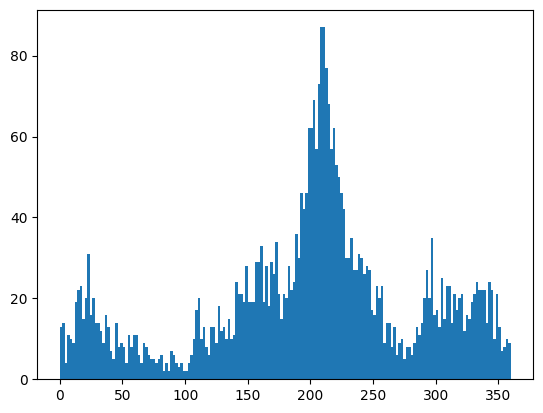

In [23]:
plt.hist(sub9_estimated_angle, bins = 180)

(array([ 64.,   0.,   0.,   0.,   0.,  48.,   0.,   0.,   0.,   0.,  32.,
          0.,   0.,   0.,   0.,  32.,   0.,   0.,   0.,   0.,  32.,   0.,
          0.,   0.,   0.,  32.,   0.,   0.,   0.,   0.,  32.,   0.,   0.,
          0.,   0.,   0.,  48.,   0.,   0.,   0.,   0.,  64.,   0.,   0.,
          0.,   0.,  64.,   0.,   0.,   0.,   0.,  64.,   0.,   0.,   0.,
          0.,  64.,   0.,   0.,   0.,   0.,  80.,   0.,   0.,   0.,   0.,
         96.,   0.,   0.,   0.,   0.,   0.,  96.,   0.,   0.,   0.,   0.,
         96.,   0.,   0.,   0.,   0., 128.,   0.,   0.,   0.,   0., 144.,
          0.,   0.,   0.,   0., 160.,   0.,   0.,   0.,   0., 160.,   0.,
          0.,   0.,   0., 176.,   0.,   0.,   0.,   0.,   0., 192.,   0.,
          0.,   0.,   0., 192.,   0.,   0.,   0.,   0., 192.,   0.,   0.,
          0.,   0., 176.,   0.,   0.,   0.,   0., 160.,   0.,   0.,   0.,
          0., 160.,   0.,   0.,   0.,   0., 144.,   0.,   0.,   0.,   0.,
          0., 128.,   0.,   0.,   0., 

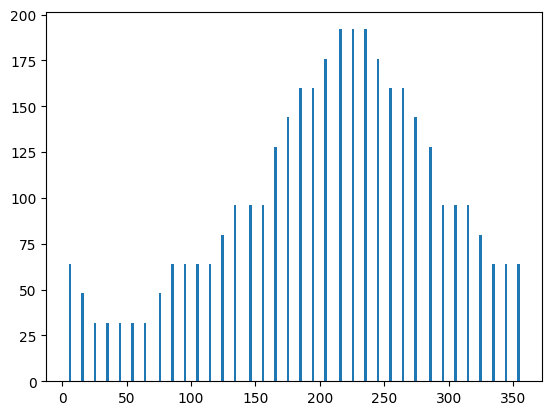

In [24]:
plt.hist(sub9_true_direction, bins = 180)

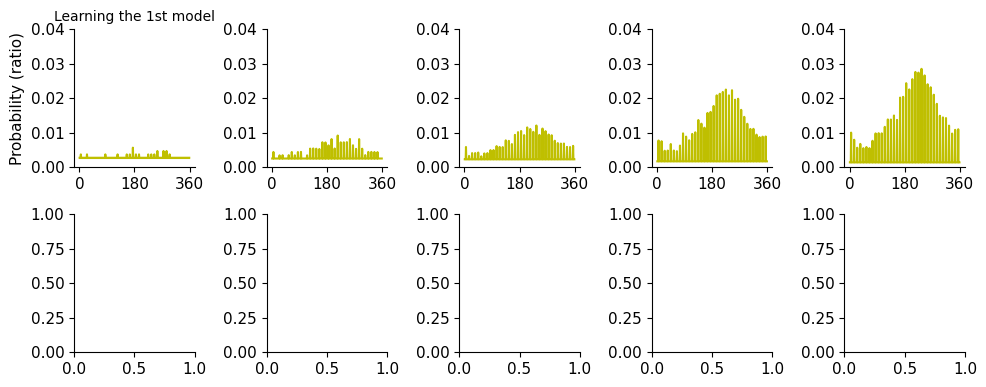

In [38]:
# @title Prior learning with a state prediction error (SPE)

# learn model 1
x = np.arange(1, 360, 1)
priors01 = learn_generative_process(sub9_true_direction, learning_rate=0.001, x=x, n_trials=800)

# # learn model 2
# priors02 = learn_generative_process(directions_prior02, learning_rate=0.001, x=x, n_trials=800)

# figure
steps = [20, 100, 200, 500, 700]
fig, axes = plt.subplots(2,len(steps), figsize=(10,4))

# plot model 1
axes[0,0].plot(x, initial_prior, color=[0.75, 0.75, 0]);
for ix, step in enumerate(steps):
  axes[0,ix].plot(x, priors01[step], color=[0.75, 0.75, 0]);
  axes[0,ix].set_xticks([0, 180, 360])
  axes[0,ix].set_xticklabels([0, 180, 360])
  axes[0,ix].set_ylim([0, 0.04])
  axes[0,0].set_title("Learning the 1st model", fontsize=10)
  if ix==0:
    axes[0,0].set_ylabel("Probability (ratio)")

# # plot model 2
# axes[1,0].plot(x, initial_prior, color= [1,0,0]);
# for ix, step in enumerate(steps):
#   axes[1,ix].plot(x, priors02[step], color= [1,0,0]);
#   axes[1,ix].set_xticks([0, 180, 360])
#   axes[1,ix].set_xticklabels([0, 180, 360])
#   axes[1,ix].set_xlabel("Motion directions (deg)")
#   axes[1,ix].set_ylim([0, 0.04])
#   axes[1,0].set_title("Learning the 2nd model", fontsize=10)
#   if ix==0:
#     axes[1,0].set_ylabel("Probability (ratio)")
# plt.tight_layout()

In [39]:
sub9_40std = sub9.loc[sub9['prior_std']==40]
sub9_40std

,trial_index,subject_id,session_id,experiment_id,run_id,motion_direction,estimated_angle,error_prior,true_error,reaction_time,motion_coherence,prior_std,true_to_prior,experiment_name
56465,1,9,1,12,5,215,234.192860,9.191247,19.191717,1.624477,0.06,40,10,data01_direction4priors
56466,2,9,1,12,5,255,193.037381,31.961578,61.962250,2.640104,0.06,40,30,data01_direction4priors
56467,3,9,1,12,5,215,224.126965,0.871059,9.129411,0.845101,0.24,40,10,data01_direction4priors
56468,4,9,1,12,5,245,222.621043,2.379028,22.379788,0.783223,0.12,40,20,data01_direction4priors
56469,5,9,1,12,5,265,247.710628,22.710241,17.287260,0.885101,0.06,40,40,data01_direction4priors
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63763,198,9,8,12,38,225,222.640785,2.358620,2.358620,1.272883,0.06,40,0,data01_direction4priors
63764,199,9,8,12,38,245,219.286394,5.713818,25.714578,0.965804,0.06,40,20,data01_direction4priors
63765,200,9,8,12,38,215,233.640785,8.642354,18.642824,1.287985,0.12,40,10,data01_direction4priors
63766,201,9,8,12,38,255,309.632888,84.636107,54.635436,1.018815,0.06,40,30,data01_direction4priors


In [63]:
# @title Generative Model

# assuming gaussian distribution for both

# Model parameters
PRIOR_MEAN = 225  # prior mean
PRIOR_STD = 40    # subject 9
SENSORY_NOISE_STD_DEG = 15 # standard deviation - might need to change
motion_direction = priors01

# This would be the actual stimulus presented to subject 9 for this trial
true_stimulus_direction = random.choice(motion_direction)# Example: assuming subject 9's true stimulus was 220 degrees
steps = 3616 # can change
likelihood_mean = 225 # should be same as motion_direction
likelihood_std = SENSORY_NOISE_STD_DEG # likelihood standard deviation for this trial

total_estimates = []
prob_select_L = 0.4 # output from logistic regression - change

for i in range(steps):
  np.random.seed(42) # set a seed for reproducibility of this single estimate

  if np.random.rand() < prob_select_L:
    # observer selects the likelihood
    estimate = np.random.normal(loc=likelihood_mean, scale=likelihood_std)
    #print(f"Decision: Selected Likelihood (Prob: {prob_select_L:.2f})")
  else:
    # observer selects the prior
    estimate = np.random.normal(loc=PRIOR_MEAN, scale=PRIOR_STD)
    #print(f"Decision: Selected Prior (Prob: {1 - prob_select_L:.2f})")

  # Wrap the estimate to 0-360 degrees
  final_estimate = np.mod(estimate, 360)
  total_estimates.append(final_estimate)

#print(f"Generated Estimate for this trial: {final_estimate:.2f} degrees")



(array([13., 14.,  4., 11., 10.,  9., 19., 22., 23., 15., 20., 31., 16.,
        20., 14., 14., 12.,  9., 16., 13.,  7.,  5., 14.,  8.,  9.,  8.,
         4., 11.,  8., 11., 11.,  6.,  4.,  9.,  8.,  6.,  5.,  5.,  4.,
         5.,  6.,  2.,  4.,  2.,  7.,  6.,  4.,  3.,  4.,  2.,  2.,  4.,
         6., 10., 17., 20., 10., 13.,  8.,  6., 13., 13.,  9., 18., 12.,
        13., 10., 15., 10., 11., 24., 21., 21., 19., 28., 19., 19., 19.,
        29., 29., 33., 19., 28., 18., 29., 26., 34., 21., 15., 21., 20.,
        28., 22., 24., 36., 30., 46., 42., 46., 62., 62., 69., 57., 73.,
        87., 87., 77., 68., 57., 62., 53., 50., 46., 42., 30., 30., 35.,
        27., 27., 31., 30., 26., 28., 27., 17., 16., 23., 20., 23.,  9.,
        14., 14.,  8., 13.,  6.,  9., 10.,  5.,  8.,  8.,  6.,  9., 13.,
        11., 14., 20., 27., 20., 35., 16., 17., 13., 25., 15., 23., 23.,
        14., 21., 17., 20., 21., 12., 16., 15., 19., 21., 24., 22., 22.,
        22., 14., 24., 22., 10., 21., 13.,  7.,  8.

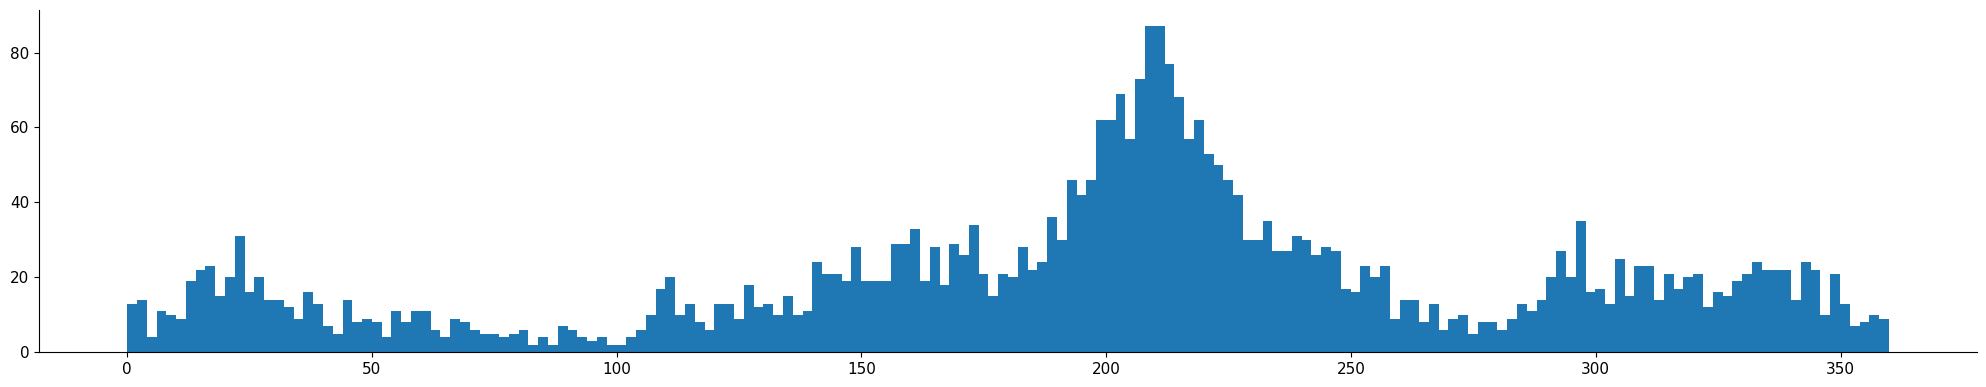

In [64]:
plt.hist(sub9_estimated_angle, bins = 180)